In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from glob import glob   # To open files
from scipy.stats import chi2 # to obtain the p-value from the chi squared

# Size plots & labels
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 14

# Data Acquisition

In [2]:
from pydaqmx_helper.adc import ADC

myADC = ADC()
myADC.addChannels([0])

Activated Channel 0


In [ ]:
V = np.zeros(3125)
V_err = np.zeros(3125)
for i in range(3125):   # 3125 data points
    data = myADC.sampleVoltages(100, 5000)[0]   # Take 100 measurements at 5000 measurements per second as 1 data point
    V[i] = np.mean(data)
    V_err[i] = np.std(data)/np.sqrt(100)   # Standard mean on the error

<ErrorbarContainer object of 3 artists>

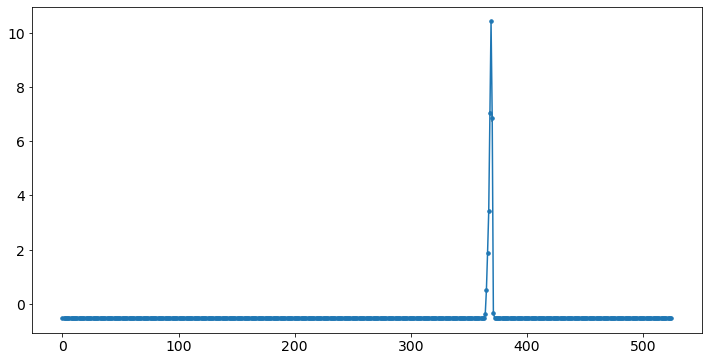

In [18]:
iterations = np.arange(525)
plt.errorbar(iterations, V, yerr=V_err, ecolor='grey', marker='o', ms=3.5)
#plt.xlim(2900,3125)

In [34]:
#np.savetxt('Downloads/Hg_650_400_5.csv', np.column_stack((V, V_err)), header='V, V_err')

# Calibration

## Calibration (single measurement)

In [2]:
# Import calibration data
V_laser, V_laser_err = np.loadtxt('Data/_laser_650_400.csv', unpack=True, delimiter=' ', skiprows=1)
V_Hg, V_Hg_err = np.loadtxt('Data/_Hg_650_400_0.csv', unpack=True, delimiter=' ', skiprows=1)
V_Na, V_Na_err = np.loadtxt('Data/_Na_650_400_0.csv', unpack=True, delimiter=' ', skiprows=1)

# Find peaks & their properties
laser_peaks, laser_props = find_peaks(V_laser, height=0)
Hg_peaks, Hg_props = find_peaks(V_Hg, height=0)
Na_peaks, Na_props = find_peaks(V_Na, height=0)

# Create dataset
dataset = [
    {"source": "Laser", "V": V_laser, "V_err": V_laser_err, "wl_th": [632.816], "peaks": laser_peaks, "peak_heights": laser_props["peak_heights"]},
    {"source": "Hg", "V": V_Hg, "V_err": V_Hg_err, "wl_th": [546.0735, 435.8328], "peaks": Hg_peaks, "peak_heights": Hg_props["peak_heights"]},
    {"source": "Na", "V": V_Na, "V_err": V_Na_err, "wl_th": [588.9950], "peaks": Na_peaks, "peak_heights": Na_props["peak_heights"]}
]


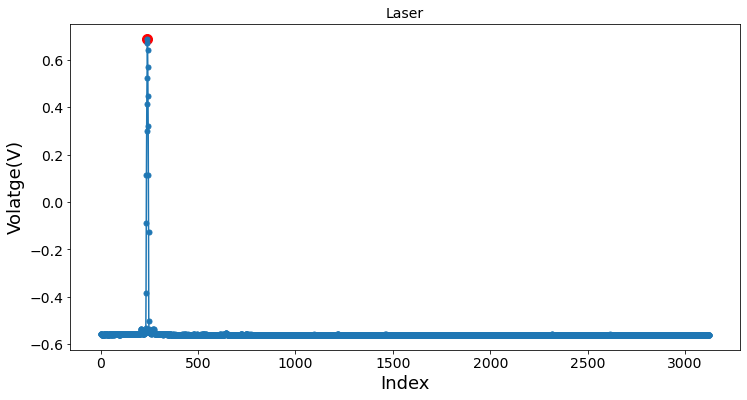

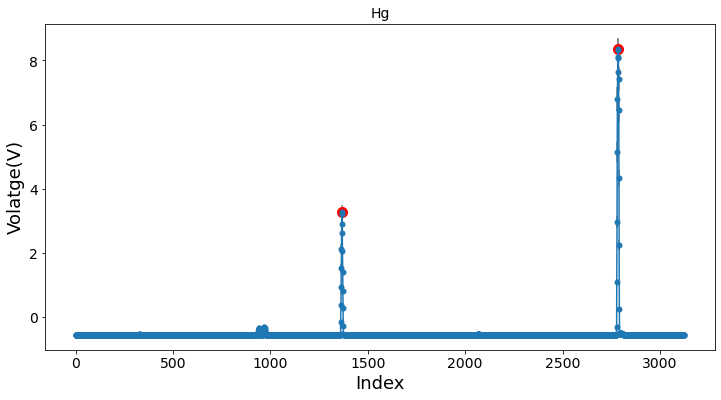

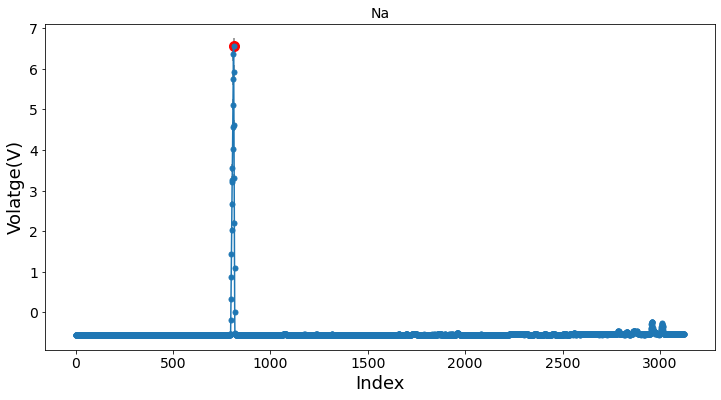

In [41]:
# Plot spectra of all sources
iterations = np.arange(len(V_laser))
for ds in dataset:
    plt.errorbar(iterations, ds['V'], yerr=abs(ds['V_err']), ecolor='grey', marker='o', ms=5)
    plt.scatter(ds['peaks'], ds['peak_heights'], color='r', marker='o', s=100, zorder=2)
    #plt.xlim(900,1000)
    #plt.ylim(-0.6, -0.3)
    plt.xlabel('Index')
    plt.ylabel('Volatge(V)')
    plt.title(ds['source'])
    plt.show()

Best-fit line: -0.0775x + 651.6849
Uncertainties on: m = 0.0002, c = 0.2758


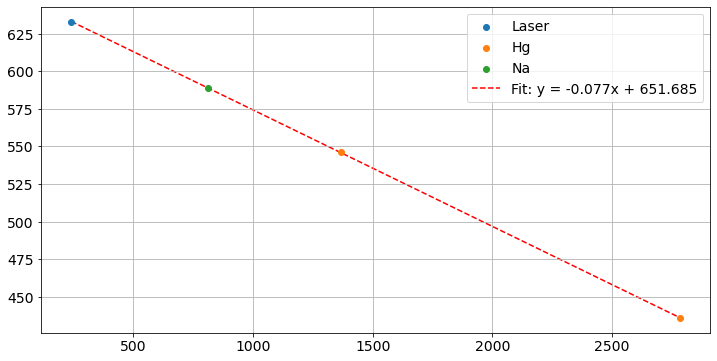

In [42]:
# Define function of a straight line for best-fit-line of calibration
def f(x,m,c):
    return m*x + c

# Initialize variables to store data points of peaks
peakses, wl_ths = [], []

# Store and plot the data points
for ds in dataset:
    peakses.extend(ds['peaks'])
    wl_ths.extend(ds['wl_th'])
    
    plt.scatter(ds['peaks'], ds['wl_th'], label=ds['source'])

# Obtain values for best fit
popt, pcov = curve_fit(f, peakses, wl_ths)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# Print them for a visual check
print(f"Best-fit line: {m:.4f}x + {c:.4f}")
print(f"Uncertainties on: m = {m_err:.4f}, c = {c_err:.4f}")

# Plot the line
xfit = np.linspace(min(peakses), max(peakses), 5000)
yfit = f(xfit, m, c)
plt.plot(xfit, yfit, 'r--', label=f"Fit: y = {m:.3f}x + {c:.3f}", zorder=0)

plt.legend()
plt.grid()
plt.show()

## Multimeasurements

For Mercury (Hg), two additional spectral lines appeared toward the end of the spectrum, but only in some of the measurements. The reason they only showed up in <u>some</u> runs and not in <u>all</u> is likely due to starting the recording slightly later in those cases and/or the motor skipping certain wavelengths.

An attempt was made to include these lines in the calibration, but it was not successful. This is because, since they appeared only under <u>specific conditions</u>, incorporating them (without properly accounting for their true positions in the runs where they were not visible) would have introduced th ebias of only choosing runs which had the same set of conditions. This bias would reduce the errors to unrealistically small values, ultimately changing the calibration line.

In order to avoid the inclusion of these lines, only data points before the mark 3000 were considered. This restriction does not affect any other spectral line from any other source.

In [2]:
# Define a function to find the average position of all the peaks in all of the calibration sources
def get_peak_pos(paths, plot=False):
    file_list = glob(paths)
    peaks_pos = []
    
    for file in file_list:
        V, V_err = np.loadtxt(file, unpack=True, delimiter=' ', skiprows=1)
        pos, props = find_peaks(V[:3000], height=0)   # Identify peaks
        peaks_pos.append(pos)

        # Visual check
        if plot==True:
            iterations = np.arange(len(V))
            plt.errorbar(iterations, V, yerr=abs(V_err), marker='o', ms=3.5, ecolor='grey')
            plt.scatter(pos, props['peak_heights'], color='red', s=80, zorder=1)
            plt.xlim(3000,)
            plt.ylim(-0.6, 0)
            plt.show()
    return np.mean(peaks_pos, axis=0), np.std(peaks_pos, axis=0)

In [3]:
# Import calibration data
laser_paths = "Data/laser*.csv"
Hg_paths = "Data/Hg*.csv"
Na_paths = "Data/Na*.csv"

# Obtain position of peaks
laser_pos, laser_pos_err = get_peak_pos(laser_paths)
Hg_pos, Hg_pos_err = get_peak_pos(Hg_paths)
Na_pos, Na_pos_err = get_peak_pos(Na_paths)

# Create dataset
dataset = {
    "Laser": {"peaks": laser_pos, "peaks_err": laser_pos_err, "wl_th": [632.816]},
    "Hg": {"peaks": Hg_pos, "peaks_err": Hg_pos_err, "wl_th": [546.0735, 435.8328]},
    "Na": {"peaks": Na_pos, "peaks_err": Na_pos_err, "wl_th": [589.5924, 588.9950]}
}

In [4]:
# Define function of a straight line for best-fit-line of calibration
def f(x,m,c):
    return m*x + c

# Define function to test goodness of fit
def chi_squared(measured, expected, measured_err, n_params):
    chi_sq = np.sum(((measured-expected) / measured_err)**2)
    dof = len(measured) - n_params
    p_val = chi2.sf(chi_sq, dof)
    return chi_sq, p_val

Best-fit line: -12.6549x + 8231.7026
Uncertainties on: m = 0.1109, c = 68.6586


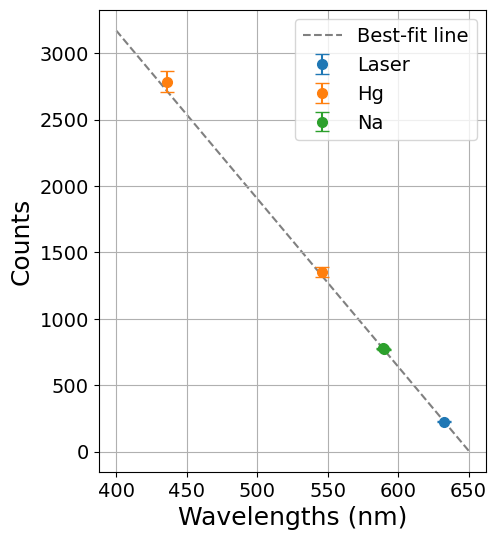

Chi-squared = 1.67, p-value = 0.644


In [5]:
plt.rcParams['figure.figsize'] = (5, 6)

# Initialize variables to store data points of peaks
peakses, peakses_err, wl_ths = [], [], []
# Store and plot the data points
for ds in dataset:
    peakses.extend(dataset[ds]['peaks'])
    peakses_err.extend(dataset[ds]['peaks_err'])
    wl_ths.extend(dataset[ds]['wl_th'])
    
    plt.errorbar(dataset[ds]['wl_th'], dataset[ds]['peaks'], yerr=dataset[ds]['peaks_err'], label=ds, marker ='o', ms=7, ls='None', capsize=5)

# Obtain values for best fit
popt, pcov = curve_fit(f, wl_ths, peakses, sigma=peakses_err, absolute_sigma=True)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))
# Print them for a visual check
print(f"Best-fit line: {m:.4f}x + {c:.4f}")
print(f"Uncertainties on: m = {m_err:.4f}, c = {c_err:.4f}")

# Plot the line
xfit = np.linspace(650, 400, 500)
yfit = f(xfit, m, c)
plt.plot(xfit, yfit, color='grey', ls='--', label="Best-fit line", zorder=0)

plt.xlabel('Wavelengths (nm)')
plt.ylabel('Counts')
plt.legend()
plt.grid()
plt.savefig("calibration_line.png", dpi=300, bbox_inches='tight')
plt.show()

# Use the chi_squared function
chi_sq, p_val = chi_squared(peakses, f(np.array(wl_ths), m, c), peakses_err, len(popt))
print(f"Chi-squared = {chi_sq:.2f}, p-value = {p_val:.3f}")

plt.rcParams['figure.figsize'] = (12,6)

## Calibration (including 2 extra Hg lines)

In [101]:
# Define a function to find the average position of all the peaks in all of the calibration sources
def get_peak_pos(paths, plot=False, extra=False):
    file_list = glob(paths)
    peaks_pos = []
    
    for file in file_list:
        V, V_err = np.loadtxt(file, unpack=True, delimiter=' ', skiprows=1)
        if extra: 
            pos, props = find_peaks(V[3000:], height=-0.3)   # Identify peaks
            pos+=3000
        else: pos, props = find_peaks(V[:3000], height=0)
        peaks_pos.append(pos)

        # Visual check
        if plot==True:
            iterations = np.arange(len(V))
            plt.errorbar(iterations, V, yerr=abs(V_err), marker='o', ms=3.5, ecolor='grey')
            plt.scatter(pos, props['peak_heights'], color='red', s=80, zorder=1)
            plt.show()
    return np.mean(peaks_pos, axis=0), np.std(peaks_pos, axis=0)

In [106]:
# Import calibration data
laser_paths = "Data/laser*.csv"
Hg_paths = "Data/Hg*.csv"
Hg_extra_paths = "Data/Hg_extra*.csv"
Na_paths = "Data/Na*.csv"

# Obtain position of peaks
laser_pos, laser_pos_err = get_peak_pos(laser_paths)
Hg_pos, Hg_pos_err = get_peak_pos(Hg_paths)
Hg_extra_pos, Hg_extra_pos_err = get_peak_pos(Hg_extra_paths, extra=True)
Na_pos, Na_pos_err = get_peak_pos(Na_paths)

# Create dataset
dataset = {
    "Laser": {"peaks": laser_pos, "peaks_err": laser_pos_err, "wl_th": [632.816]},
    "Hg": {"peaks": Hg_pos, "peaks_err": Hg_pos_err, "wl_th": [546.0735, 435.8328]},
    "Hg_extra": {"peaks": Hg_extra_pos, "peaks_err": Hg_extra_pos_err, "wl_th": [404.6563, 398.3931]},
    "Na": {"peaks": Na_pos, "peaks_err": Na_pos_err, "wl_th": [589.5924, 588.9950]}
}

Best-fit line: -12.2823x + 8000.6072
Uncertainties on: m = 0.0186, c = 10.3335


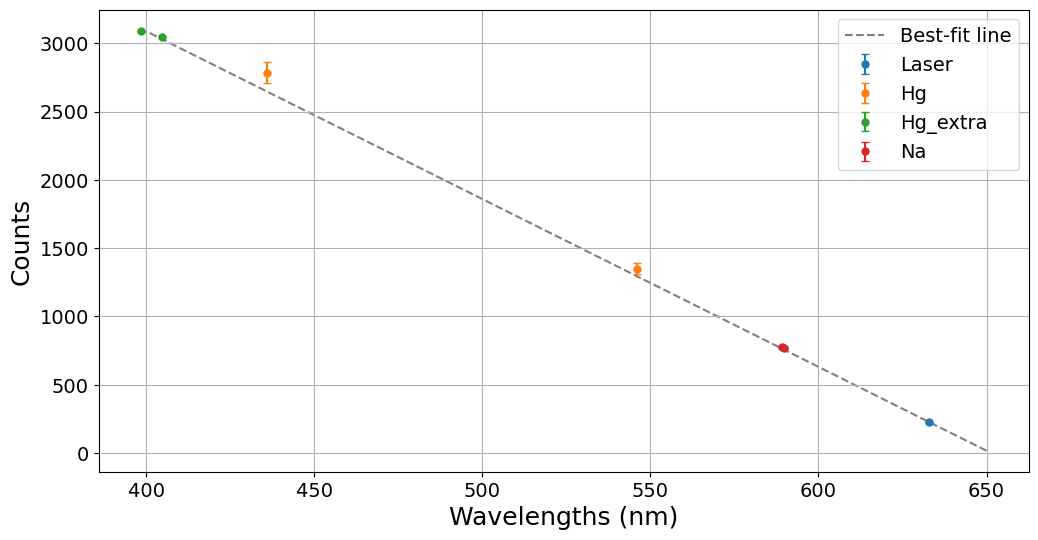

In [107]:
# Define function of a straight line for best-fit-line of calibration
def f(x,m,c):
    return m*x + c

# Initialize variables to store data points of peaks
peakses, peakses_err, wl_ths = [], [], []

# Store and plot the data points
for ds in dataset:
    peakses.extend(dataset[ds]['peaks'])
    peakses_err.extend(dataset[ds]['peaks_err'])
    wl_ths.extend(dataset[ds]['wl_th'])
    
    plt.errorbar(dataset[ds]['wl_th'], dataset[ds]['peaks'], yerr=dataset[ds]['peaks_err'], label=ds, marker ='o', ms=5, ls='None', capsize=3)

# Obtain values for best fit
popt, pcov = curve_fit(f, wl_ths, peakses, sigma=peakses_err, absolute_sigma=True)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

# Print them for a visual check
print(f"Best-fit line: {m:.4f}x + {c:.4f}")
print(f"Uncertainties on: m = {m_err:.4f}, c = {c_err:.4f}")

# Plot the line
xfit = np.linspace(650, 400, 500)
yfit = f(xfit, m, c)
plt.plot(xfit, yfit, color='grey', ls='--', label="Best-fit line", zorder=0)

plt.xlabel('Wavelengths (nm)')
plt.ylabel('Counts')
plt.legend()
plt.grid()
plt.show()

# Data Anlaysis

## Wavelength offset

Same way recording of calibration might not have started at exactly 650.0 nm, these recording might not be exact either. Some peaks from iodine will be identified in order to properly align the wavelengths with the recordings and a pair of without-iodine recording that folows a similar trend (since they changed slightly) and has the peak around the same point in the x-axis.

### Check for best fit overlapping

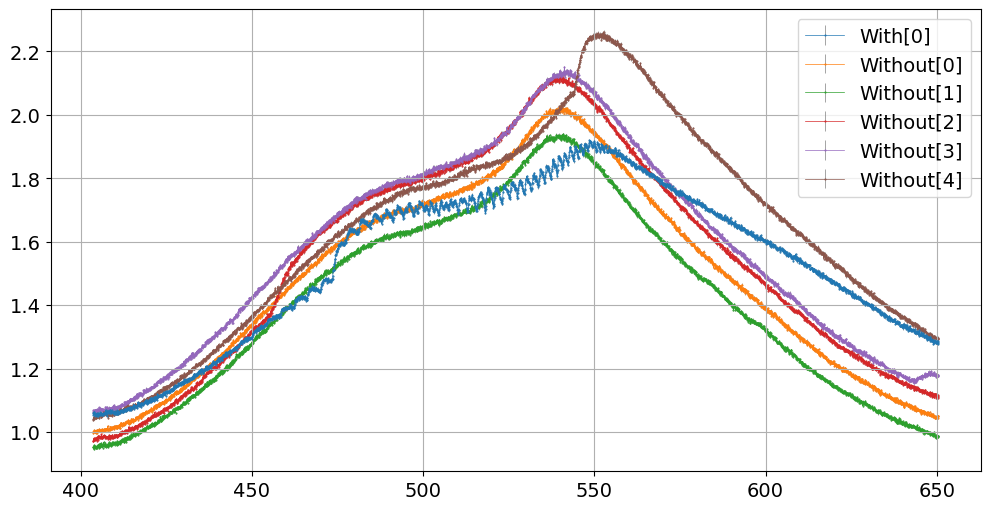

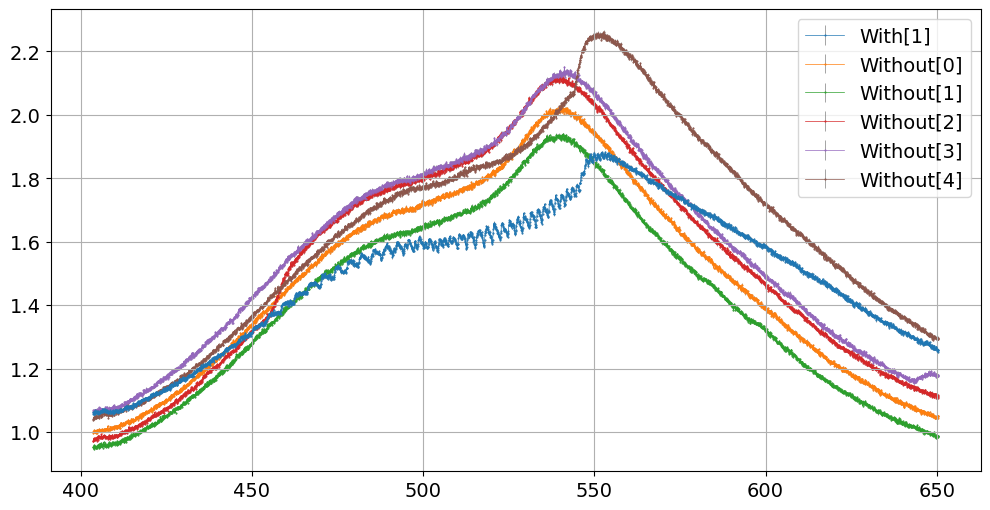

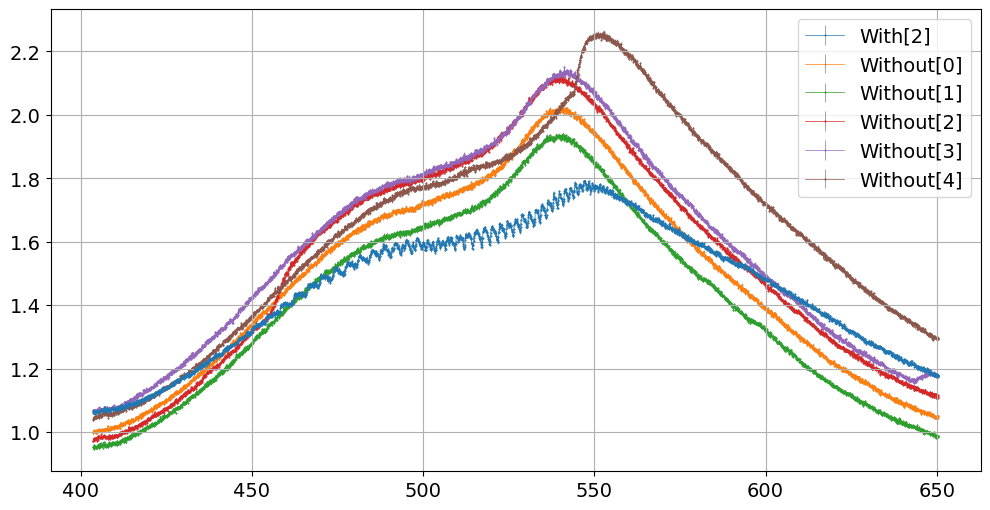

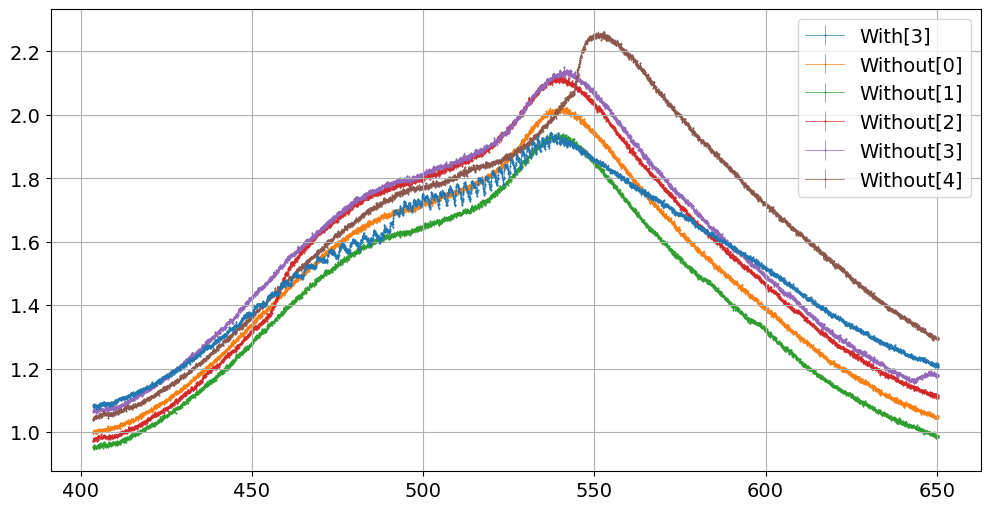

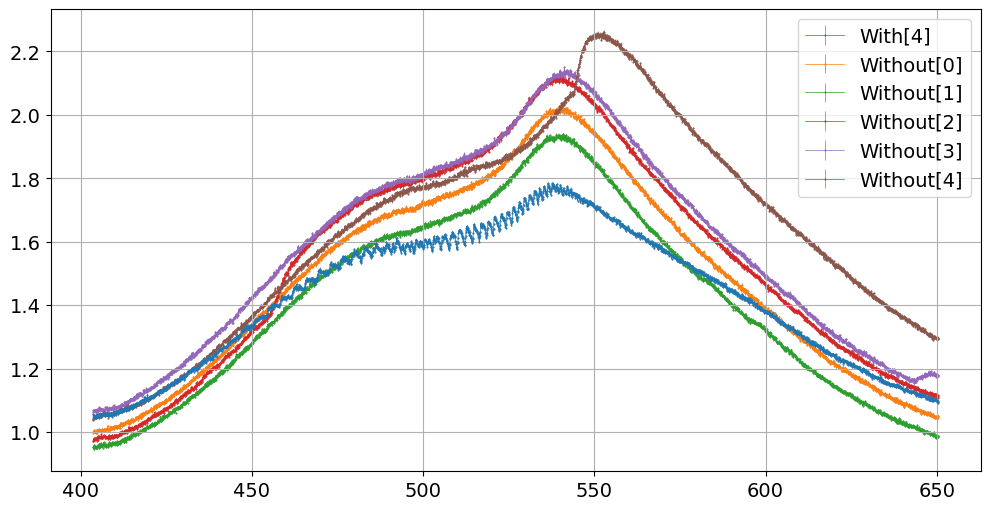

In [6]:
iterations = np.arange(3125)
wavelengths = (iterations - c) / m

# Import data for tungsen lamp with iodine
tungsen_w_paths = 'Data/tungsen_w_*.csv'
tungsen_w_files = glob(tungsen_w_paths)

# Import data for tungsen lamp without iodine
tungsen_wo_paths = 'Data/tungsen_wo_*.csv'
tungsen_wo_files = glob(tungsen_wo_paths)

# Rotate through w_files while plotting all of wo_files to find a match
for j in range(len(tungsen_w_files)):
    file_w = tungsen_w_files[j]

    V_w, V_w_err = np.loadtxt(file_w, unpack=True, delimiter=' ', skiprows=1)
    plt.errorbar(wavelengths[::-1], V_w, yerr=V_w_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.5, label=f'With{[j]}')

    for i in range(len(tungsen_wo_files)):
        file_wo = tungsen_wo_files[i]
        V_wo, V_wo_err = np.loadtxt(file_wo, unpack=True, delimiter=' ', skiprows=1)
        plt.errorbar(wavelengths[::-1], V_wo, yerr=V_wo_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.5, zorder=0, label=f'Without{[i]}')

    #plt.xlim(520,550)
    plt.legend()
    plt.grid()
    plt.show()

### Calculate and apply offset

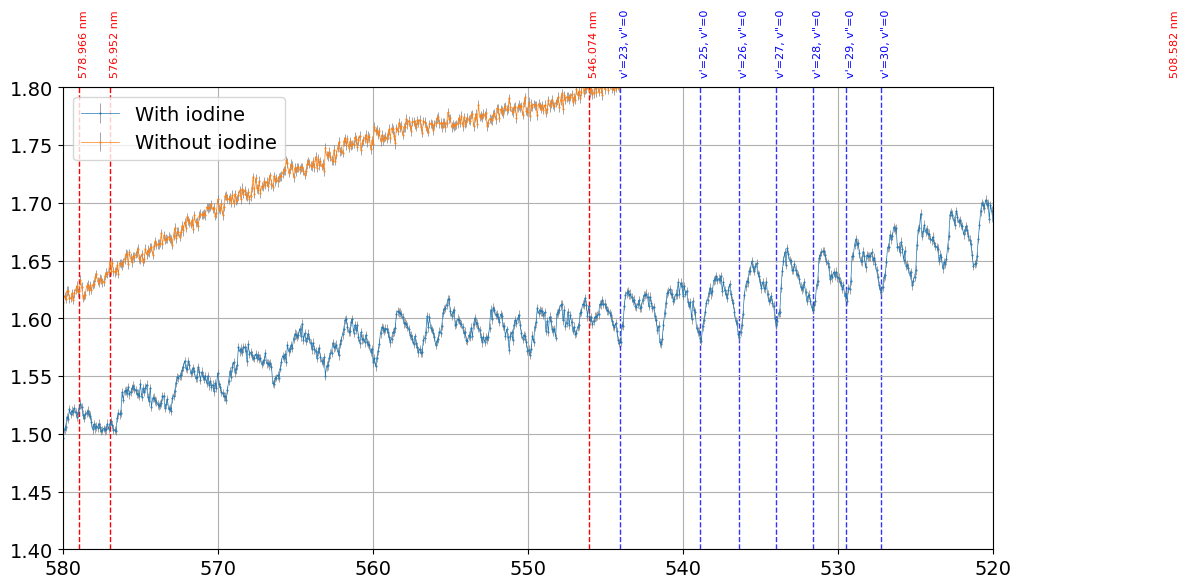

In [7]:
iterations = np.arange(3125)
wavelengths = (iterations - c) / m

# Plot curve with iodine
file_w = tungsen_w_files[1]   # Alternatively, 4
V_w, V_w_err = np.loadtxt(file_w, unpack=True, delimiter=' ', skiprows=1)
plt.errorbar(wavelengths, V_w, yerr=V_w_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.5, label='With iodine')

# Plot curve without iodine
file_wo = tungsen_wo_files[4]   # Alternetively, along with 4 above, 0
V_wo, V_wo_err = np.loadtxt(file_wo, unpack=True, delimiter=' ', skiprows=1)
plt.errorbar(wavelengths, V_wo, yerr=V_wo_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.5, label='Without iodine')


# Plot vertical red lines from paper for reference
for line in [578.966, 576.952, 546.074, 508.582]:
    plt.axvline(line, linestyle='--', color='r', linewidth=1)
    plt.text(line, 1.81, f"{line:} nm", rotation=90, color='r', fontsize=8)

# Plot vertical blue lines indicating key spots in the spectra for reference
for line, name in zip([544.1, 538.9, 536.38, 534, 531.6, 529.5, 527.2], [23, 25, 26, 27, 28, 29, 30]):
    #line = (line_pos - c) / m   # Turn into wavelength
    plt.axvline(line, linestyle='--', color='b', linewidth=1, zorder=0, alpha=0.8)
    plt.text(line, 1.81, f"v'={name}, v\"=0", rotation=90, color='b', fontsize=8)
    

plt.gca().invert_xaxis()
plt.xlim(580,520)
plt.ylim(1.4,1.8)
plt.legend()
plt.grid()
plt.show()

<img src="Screenshot_28-9-2025_141020_.jpeg" width="700" style="margin-left:240px;">

From "Iodine molecular constants from absorption and laser fluorescene", Fig 2 known spectral lines of other elements were plotted as red lines. For example, Hg shows a line 546.074 nm which coincides with v'=25, v"=0. However the lines at quantum numbers 23, 24, 25, etc. can be identified by their shape and compared to the ones in the plot above after which one can realise that they do not match. Line 23 was identified as the first big dip after what is labeled as 'section 2' in the paper, line 26 could be described the one right before what had turned into a series of 2 consecutive peaks (section 2) combines back to 1 single sharp peak. With lines 27 and 28 being the precedent of 2 peaks with quite recognisable shape due to their decrease.

The spectra both with and without iodine (since they match in shape implying the difference between starting the recording and starting the motor was similar between both runs) will now be calibrated by readjusting the spectral lines v'=26 through 30 with the values in "Band spectra and Dissociation Energies"

Wavelength offset: 9.9100
Statistical uncertainty: 0.1867 nm


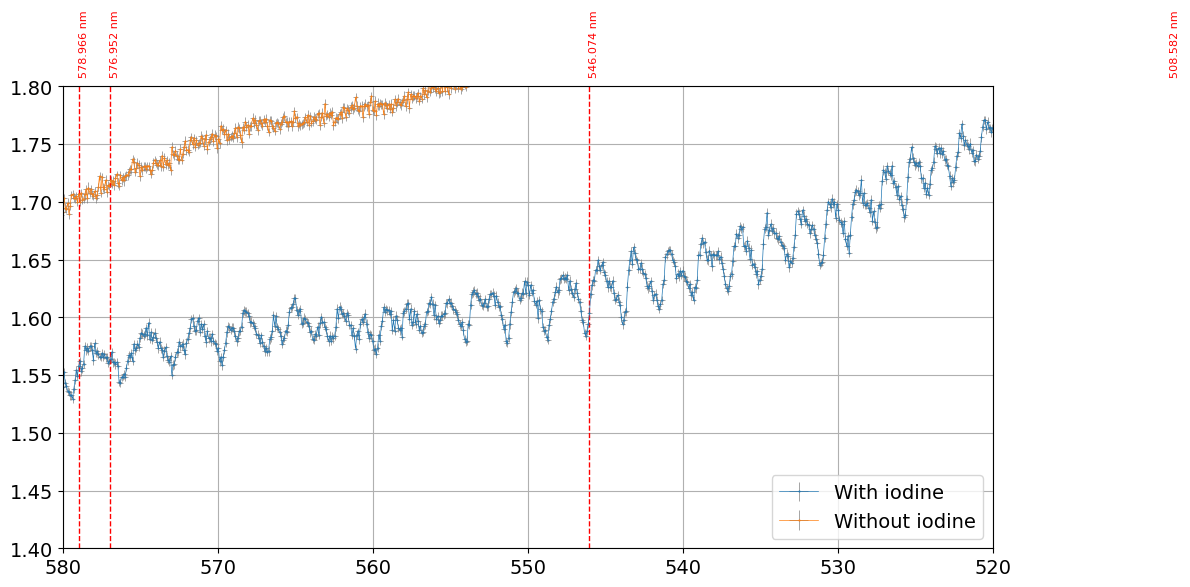

In [8]:
# Bands wavelengths
th_wl = [546.82, 543.47, 541.18, 539.89, 536.87]
obs_wl = [536.38, 534, 531.6, 529.5, 527.2]
# To compensate for manually choosing the line wavelength
iter_uncertainty = 1   # iteration uncertainty
iter_to_nm = abs( m**(-1) )   # nm per iteration
wl_err = iter_uncertainty * iter_to_nm   # nm

# Calculate and apply offset
differences = [i-j for i,j in zip(th_wl,obs_wl)]
wl_offset = np.mean(differences)
print(f"Wavelength offset: {wl_offset:.4f}")
wl_offset_err = np.std(differences)/np.sqrt(len(differences))
print(f'Statistical uncertainty: {wl_offset_err:.4f} nm')

# Apply and plot
wavelengths = (iterations - c) / m
wavelengths += wl_offset
plt.errorbar(wavelengths, V_w, xerr=wl_offset_err, yerr=V_w_err, marker='o', ms=0.5, linewidth=0.5, ecolor='grey', label='With iodine')
plt.errorbar(wavelengths, V_wo, xerr=wl_offset_err, yerr=V_wo_err, marker='o', ms=0.5, linewidth=0.5, ecolor='grey', label='Without iodine')

# Plot vertical red lines from paper for reference
for line in [578.966, 576.952, 546.074, 508.582]:
    plt.axvline(line, linestyle='--', color='r', linewidth=1)
    plt.text(line , 1.81, f"{line:} nm", rotation=90, color='r', fontsize=8)

plt.gca().invert_xaxis()
plt.xlim(580,520)
plt.ylim(1.4,1.8)
plt.legend()
plt.grid()
plt.show()

As a visual check, the Hg lines around 579 and 577 nm are 11 quantum numbers away from the line at 546 nm, just like in the paper

## Logarithmic plot

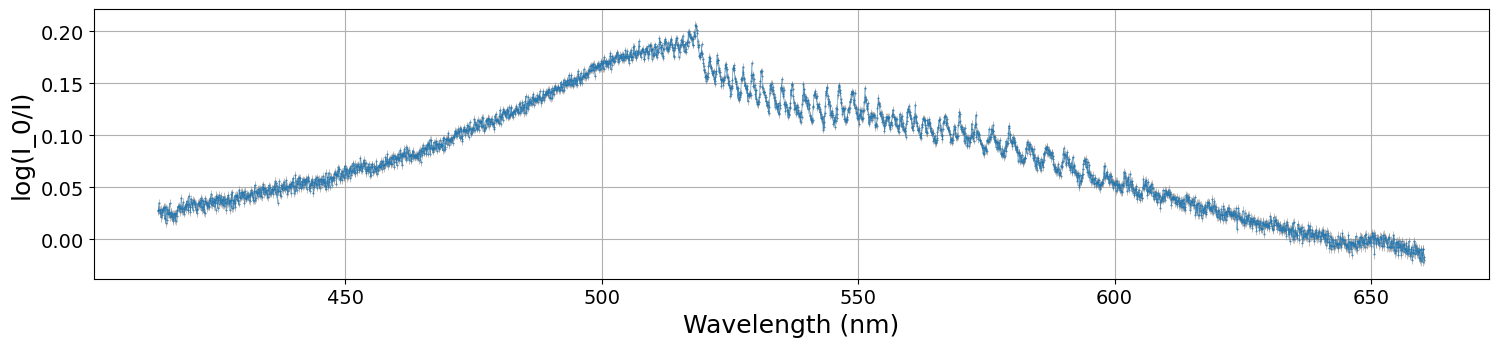

In [52]:
plt.rcParams['figure.figsize'] = (18,3.5)

# Plot the logarithm
A = np.log(V_wo/V_w)
A_err = np.sqrt((V_wo_err / V_wo)**2 + (V_w_err / V_w)**2)

plt.errorbar(wavelengths, A, xerr=wl_offset_err, yerr=A_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.5, alpha=0.7)
plt.xlabel("Wavelength (nm)")
plt.ylabel("log(I_0/I)")
plt.grid()
plt.savefig("log_plot.png", dpi=300, bbox_inches='tight')
plt.show()
plt.rcParams['figure.figsize'] = (12,6)

## 1st difference vs Quantum number

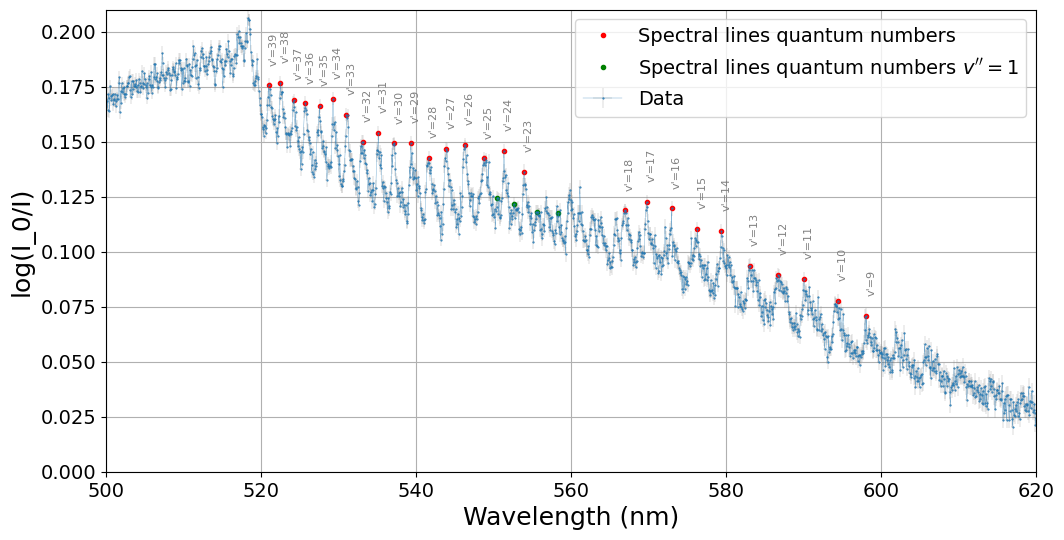

In [135]:
# Define the wavelength window
mask = ((wavelengths >= 520) & (wavelengths <= 555)) | ((wavelengths >= 565) & (wavelengths <= 620))
wl_region = wavelengths[mask]
A_region = A[mask]

# Find minima in this region
minima, props = find_peaks(A_region, prominence=0.02, distance=5)
minima_pos = wl_region[minima]
minima_depths = A_region[minima]

# Plot
plt.errorbar(wavelengths, A, xerr=wl_offset_err, yerr=A_err, ecolor='grey', marker='o', ms=0.5, linewidth=0.2, label='Data')
plt.plot(minima_pos, minima_depths, color='r', ms=3, marker='o', linestyle='None', label='Spectral lines quantum numbers')
[plt.text(x, y+0.01, f"v'={23+i}", rotation=90, color='grey', fontsize=8) 
for i, (x, y) in enumerate(zip(minima_pos[-17:], minima_depths[-17:]))]
[plt.text(x, y+0.01, f"v'={18-(len(minima_pos[:-17])-1-i)}", rotation=90, color='grey', fontsize=8) 
 for i, (x, y) in enumerate(zip(minima_pos[:-17], minima_depths[:-17]))]

# Bands for v"=1
minima_g = np.where(mask)[0][minima]
minima_v1 = [minima_g[-15]-22, minima_g[-16]-16, minima_g[-17]-21, minima_g[-17]-56]   # 27, 26, 25, 24
plt.plot(wavelengths[minima_v1], A[minima_v1], color='g', ms=3, marker='o', linestyle='None', label='Spectral lines quantum numbers $v\'\'=1$')

plt.xlim(500, 620)
plt.ylim(0, 0.21)
plt.xlabel("Wavelength (nm)")
plt.ylabel("log(I_0/I)")
plt.legend()
plt.grid()
plt.show()

The idea of including the bands from v"=1 was aboned since they had to be found manually, the signal wasn't great and there is only very little of them that can be recognised by a human eye

In [ ]:
# Manual correction of some peaks that were not properly detected - it happens more in the 2nd region sicnce peaks in 1st are more sharp and clear
minima_pos[1] = wl_region[minima[1]+4]
minima_pos[2] = wl_region[minima[2]-3]
minima_pos[5] = wl_region[minima[5]-4]

No bands past 39 or 9 can be detected. This is due to the high amount of noise and/or the lost of precision that taking measurements there would suppose

Best fit: y = (-1.8161 ± 0.0773)x + (127.3506 ± 1.9262)


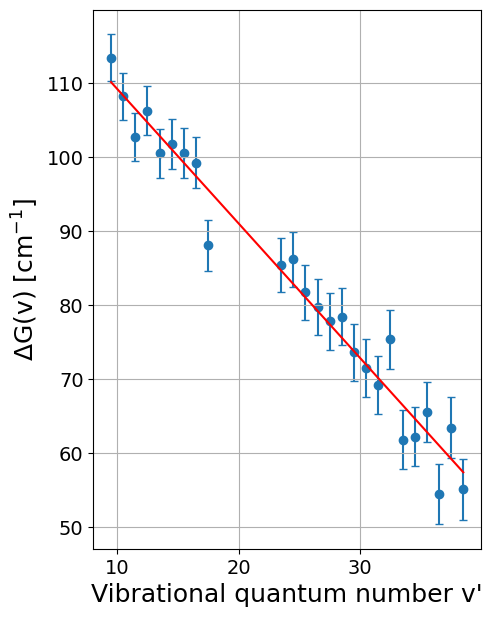

Chi-squared = 19.32, p-value = 0.683


In [12]:
plt.rcParams['figure.figsize'] = (5, 7)

# Quantum numbers
v_numbers1 = np.arange(9, 19)
v_numbers2 = np.arange(23, 40)

# Grab the middle point for plotting the differences
v_mid1 = [(v_numbers1[i]+v_numbers1[i+1])/2 for i in range(len(v_numbers1)-1)]
v_mid2 = [(v_numbers2[i]+v_numbers2[i+1])/2 for i in range(len(v_numbers2)-1)]

# Get the wavenumbers in cm^-1
wavenumbers = 1e7 / minima_pos   # convert nm to cm^-1
wavenumbers_err = 1e7 * wl_err / (minima_pos**2)   # wl_err=minima_pos_err as it is unchanged through: wavelengths, wl_region, minima_pos

# Calculate the differences and its errors
differences1 = np.diff(wavenumbers[:len(v_numbers1)])
differences2 = np.diff(wavenumbers[len(v_numbers1):])
differences1_err = np.sqrt(wavenumbers_err[1:len(v_numbers1)]**2 + wavenumbers_err[:len(v_numbers1)-1]**2)   # v_i+1 - v_i -> sqrt(Δv_i+1**2 + Δv_i**2)
differences2_err = np.sqrt(wavenumbers_err[len(v_numbers1)+1:]**2 + wavenumbers_err[len(v_numbers1):-1]**2)

# Join together
v_ = np.array(v_mid1 + v_mid2) 
DG = np.array(list(differences1) + list(differences2))
DG_err = np.array(list(differences1_err) + list(differences2_err))

# Get fit parameters
popt, pcov = curve_fit(f, v_, DG, sigma=DG_err, absolute_sigma=True)
m_fit, c_fit = popt
m_err, c_err = np.sqrt(np.diag(pcov))
print(f"Best fit: y = ({m_fit:.4f} ± {m_err:.4f})x + ({c_fit:.4f} ± {c_err:.4f})")

# Plot fit line
x_fit = np.linspace(min(v_), max(v_), 200)
y_fit = f(x_fit, m_fit, c_fit)
plt.plot(x_fit, y_fit, 'r-', label="Best-fit line")

# Plot data with error bars
plt.errorbar(v_, DG, yerr=DG_err, fmt='o', capsize=3, label="Data with errors", zorder=0)

plt.xlabel("Vibrational quantum number v'")
plt.ylabel("ΔG(v) [cm$^{-1}$]")
#plt.legend()
plt.grid()
plt.savefig("BS_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Use the chi_squared function
chi_sq, p_val = chi_squared(DG, f(np.array(v_), m_fit, c_fit), DG_err, len(popt))
print(f"Chi-squared = {chi_sq:.2f}, p-value = {p_val:.3f}")

plt.rcParams['figure.figsize'] = (12, 6)

## Obtaining the physical parameters

In [53]:
# Graphical results

WeXe = -m_fit/2
WeXe_err = m_err / 2
print(f"WeXe = {WeXe:.4f} ± {WeXe_err:.4f} cm^-1")

We = c_fit + WeXe*1   # Since We is the intercept at v=-1
We_err = np.sqrt(c_err**2 + WeXe_err**2)
print(f"We = {We:.4f} ± {We_err:.4f} cm^-1")

v_m = -c_fit/m_fit
v_m_err = np.sqrt( (c_err / m_fit)**2 + (c_fit * m_err / m_fit**2)**2 )
print(f"v_m = {v_m:.4f} ± {v_m_err:.4f}")

De = v_m * We / 2   # Area of triangle = base * height / 2
De_err = np.sqrt( (v_m * c_err / 2)**2 + (c_fit * v_m_err / 2)**2 )
print(f"De = {De:.4f} ± {De_err:.4f} cm^-1")

D0 = De - 1/2*We + 1/4*WeXe   # G(0) = 1/2*We - 1/4*WeXe + ...
D0_err = np.sqrt(De_err**2 + (1/2*We_err)**2 + (1/4*WeXe_err)**2)
print(f"D0 = {D0:.4f} ± {D0_err:.4f} cm^-1")

mu = 1.053e-22   # g
c_speed = 2.998e10   # cm/s
ke = (2*np.pi*c_speed*We)**2 * mu
ke_err = (2*np.pi*c_speed)**2 * 2*We * We_err * mu
print(f"ke = {ke:.4g} ± {ke_err:.4g} dyn/cm")

WeXe = 0.9081 ± 0.0386 cm^-1
We = 128.2587 ± 1.9266 cm^-1
v_m = 70.1217 ± 3.1666
De = 4496.8611 ± 212.6454 cm^-1
D0 = 4432.9587 ± 212.6476 cm^-1
ke = 6.146e+04 ± 1847 dyn/cm


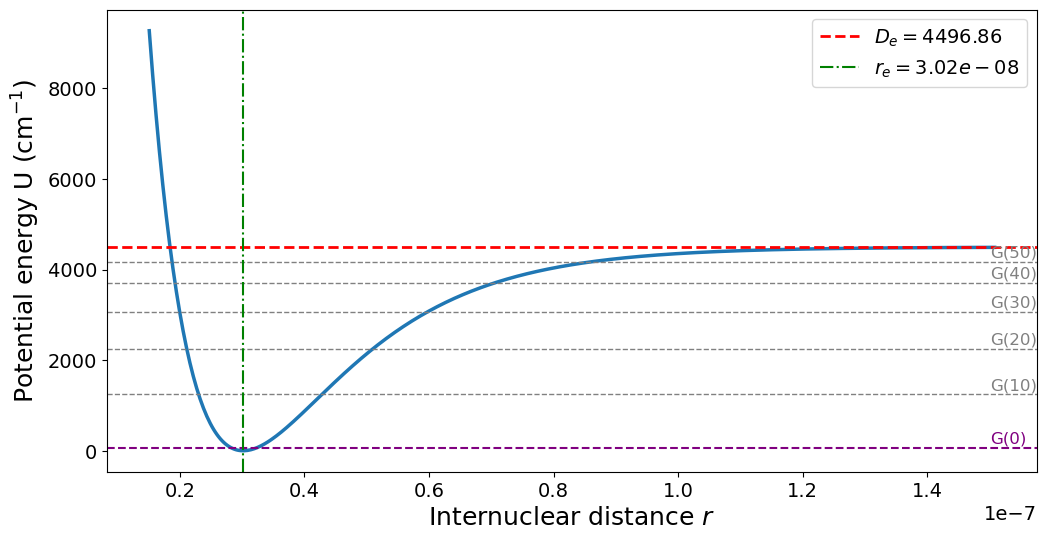

In [130]:
h = 6.62607015e-27
beta = We *np.sqrt(2*mu*c_speed/(De*h))
re = 3.016e-8
r = np.linspace(0.5*re, 5*re, 500)
U = De * (1 - np.exp(-beta * (r - re)))**2
plt.plot(r, U, linewidth=2.5, zorder=0)

# Plot
G0 = We*0.5 + WeXe*1/4
plt.axhline(G0, linestyle='--', color='purple')
plt.text(1.5e-7, G0+100, f"G(0)", color='purple', fontsize=12)

v_list = [10,20,30,40,50]
for v in v_list:
    Gv = We*(v+0.5) - WeXe*(v+0.5)**2
    plt.axhline(Gv, linestyle='--', color='grey', linewidth=1, zorder=0)
    plt.text(1.5e-7, Gv+100, f"G({v})", color='grey', fontsize=12)
    
plt.axhline(De, linestyle='--', color='r', label=f'$D_e={De:.2f}$', linewidth=2)
plt.axvline(re, linestyle='dashdot', color='g', label=f'$r_e={re:.3g}$')

plt.xlabel("Internuclear distance $r$")
plt.ylabel("Potential energy U (cm$^{-1}$)")
#plt.grid()
plt.legend()
plt.savefig("Morse_potential.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Numerical results

D2G = np.diff(DG)   # Second differences
D2G_err = np.sqrt(DG_err[1:]**2 + DG_err[:-1]**2)

WeXe = abs(np.mean(D2G)) / 2
WeXe_err = np.sqrt(np.mean(D2G_err**2)) / (2*len(D2G_err))
print(f"WeXe (numerical) = {WeXe:.4f} ± {WeXe_err:.4f} cm^-1")

We = np.mean(DG + 2 * WeXe * v_)
We_err = np.sqrt(np.mean(DG_err)**2/len(DG) + np.mean((2*v_*WeXe_err)**2)/len(v_))
print(f"We (numerical) = {We:.4f} ± {We_err:.4f} cm^-1")

Xe = WeXe/We
Xe_err = np.sqrt((WeXe_err / We)**2 + (WeXe * We_err / We**2)**2 )
print(f"Xe = {Xe:.4g} ± {Xe_err:.4g}")

v_m = 1/(2*Xe) - 1
v_m_err = Xe_err / (2 * Xe**2)
print(f"v_m (numerical) = {v_m:.4f} ± {v_m_err:.4f}")

De = We*(v_m+1/2)-WeXe*(v_m+1/2)**2   # De = G(v_m)
De_err = np.sqrt( ((v_m+1/2)*We_err)**2 + ((v_m+1/2)**2*WeXe_err)**2)
print(f"De = {De:.4f} ± {De_err:.4f} cm^-1")

D0 = De - 1/2*We + 1/4*WeXe   # G(0) = 1/2*We - 1/4*WeXe + ...
D0_err = np.sqrt(De_err**2 + (1/2*We_err)**2 + (1/4*WeXe_err)**2)
print(f"D0 = {D0:.4f} ± {D0_err:.4f} cm^-1")

mu = 1.053e-22   # g
c_speed = 2.998e10   # cm/s
ke = (2*np.pi*c_speed*We)**2 * mu
ke_err = (2*np.pi*c_speed)**2 * 2*We * We_err * mu
print(f"ke = {ke:.4g} ± {ke_err:.4g} dyn/cm")

WeXe (numerical) = 1.2138 ± 0.1089 cm^-1
We (numerical) = 142.4535 ± 1.3656 cm^-1
Xe = 0.008521 ± 0.000769
v_m (numerical) = 57.6815 ± 5.2961
De = 4179.3919 ± 377.1907 cm^-1
D0 = 4108.4686 ± 377.1913 cm^-1
ke = 7.582e+04 ± 1454 dyn/cm
